# Glioma Detection

In [1]:
# Required Imports

import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_addons as tfa
import numpy as np
import cv2
import matplotlib.cm as cm
import seaborn as sns

from tensorflow.keras.utils import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras import backend as K
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

C:\Users\praje\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [2]:
# Function used to get image and label paths

def get_data_labels(directory, shuffle=True, random_state=0):
    from sklearn.utils import shuffle
    data_path = []
    data_index = []
    label_dict = {label: index for index, label in enumerate(sorted(os.listdir(directory)))}

    for label, index in label_dict.items():
        label_dir = os.path.join(directory, label)
        for image in os.listdir(label_dir):
            image_path = os.path.join(label_dir, image)
            data_path.append(image_path)
            data_index.append(index)

    if shuffle:
        data_path, data_index = shuffle(data_path, data_index, random_state=random_state)

    return data_path, data_index

In [4]:
# Shuffling the paths we get and splitting into training and testing sets

SEED=111
USER_PATH = r"D:\one drive downloads\Documents\Capstone\Dataset"
train_paths, train_index = get_data_labels(USER_PATH + '/Training', random_state=SEED)
test_paths, test_index = get_data_labels(USER_PATH + '/Testing', random_state=SEED)

print('Training')
print(f'Number of Paths: {len(train_paths)}')
print(f'Number of Labels: {len(train_index)}')
print('\nTesting')
print(f'Number of Paths: {len(test_paths)}')
print(f'Number of Labels: {len(test_index)}')

class_mappings = {'Glioma': 0, 'Meninigioma': 1, 'Notumor': 2, 'Pituitary': 3}
class_names = list(class_mappings.keys())

Training
Number of Paths: 5712
Number of Labels: 5712

Testing
Number of Paths: 1311
Number of Labels: 1311


In [5]:
# Taking a slice of training set for more generalization

random.seed(SEED)

sample_indices = random.sample(range(len(train_paths)), 4000)

train_paths_sampled = [train_paths[i] for i in sample_indices]
train_index_sampled = [train_index[i] for i in sample_indices]

print(f'Sampled Training Paths: {len(train_paths_sampled)}')
print(f'Sampled Training Labels: {len(train_index_sampled)}')

Sampled Training Paths: 4000
Sampled Training Labels: 4000


In [6]:
index_to_class = {v: k for k, v in class_mappings.items()}

def show_images(paths, label_paths, class_mappings, index_list=range(10), im_size=250, figsize=(12, 8)):

    num_images = len(index_list)
    num_rows = (num_images + 3) // 5
    _, ax = plt.subplots(nrows=num_rows, ncols=5, figsize=figsize)
    ax = ax.flatten()

    for i, index in enumerate(index_list):
        if i >= num_images:
            break
        image = load_img(paths[index], target_size=(im_size, im_size), color_mode='grayscale')
        ax[i].imshow(image, cmap='Greys_r')
        class_name = index_to_class[label_paths[index]]
        ax[i].set_title(f'{index}: {class_name}')
        ax[i].axis('off')

    plt.tight_layout()
    plt.show()

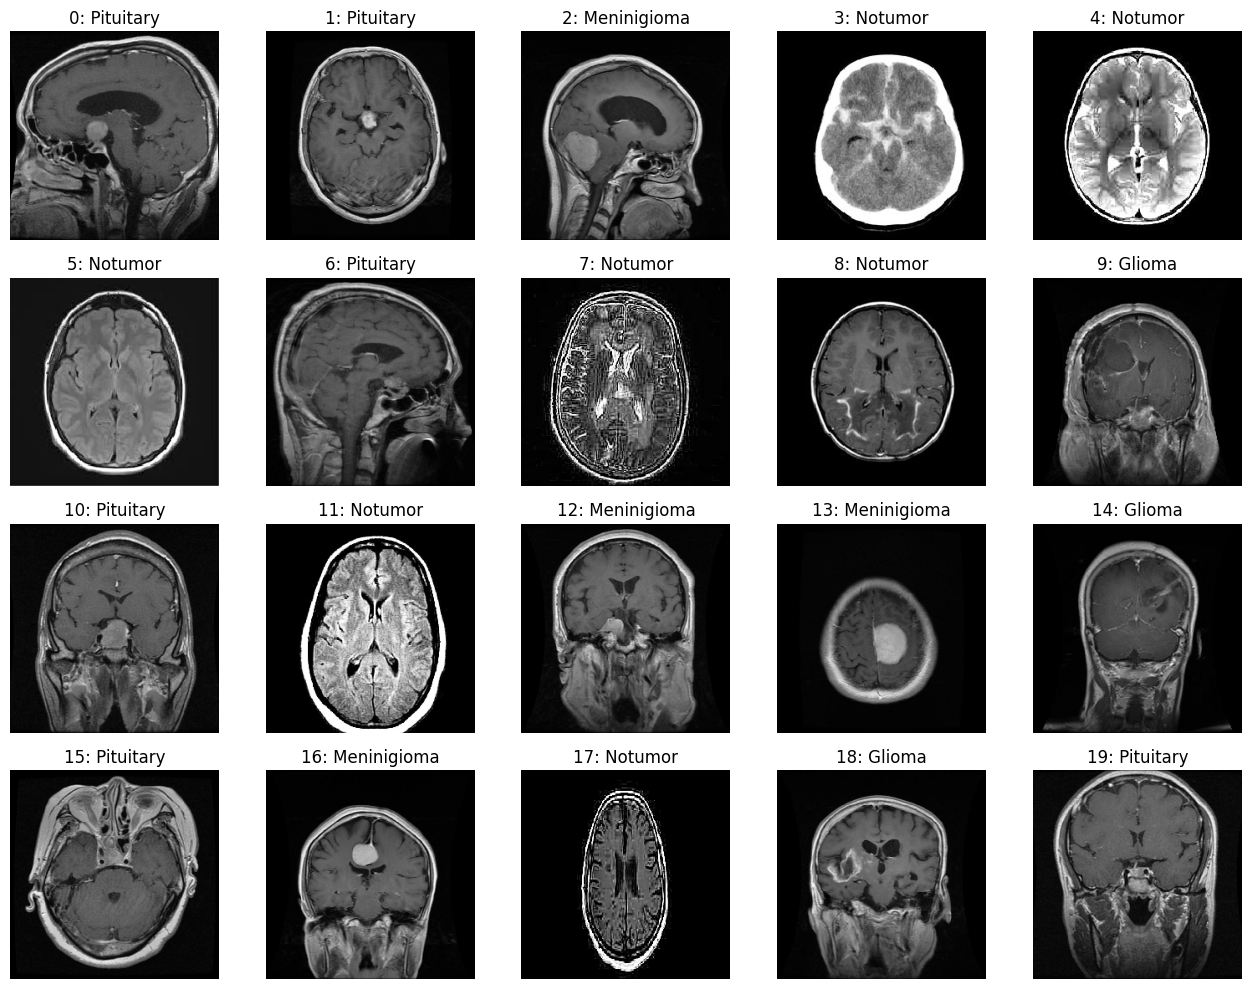

In [7]:
show_images(train_paths_sampled, train_index_sampled, class_mappings, im_size=250, figsize=(13,10),index_list=range(0, 20))

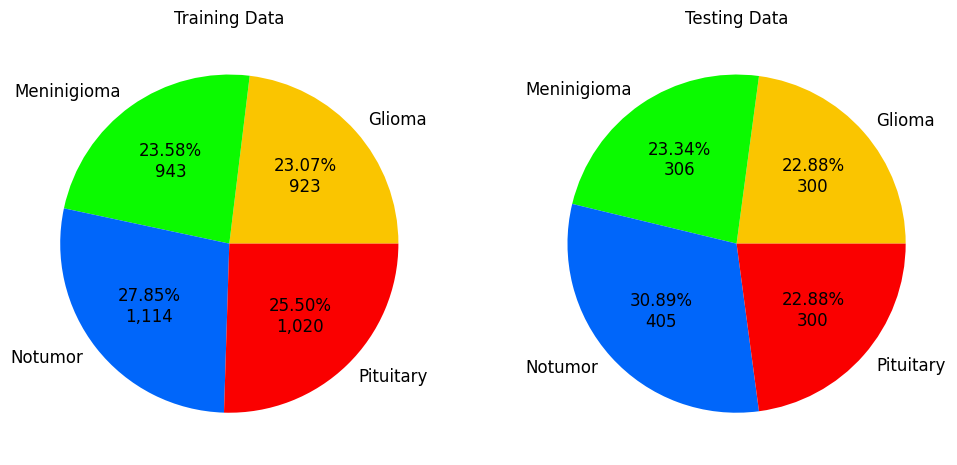

In [8]:
_, ax = plt.subplots(ncols=2, figsize=(12, 8))

class_counts = [len([x for x in train_index_sampled if x == label]) for label in set(train_index_sampled)]
ax[0].set_title('Training Data')
ax[0].pie(
    class_counts,
    labels=[label for label in class_names],
    colors=['#FAC500','#0BFA00', '#0066FA','#FA0000'],
    autopct=lambda p: '{:.2f}%\n{:,.0f}'.format(p, p * sum(class_counts) / 100),
    textprops={'fontsize': 12}
)

class_counts = [len([x for x in test_index if x == label]) for label in set(test_index)]
ax[1].set_title('Testing Data')
ax[1].pie(
    class_counts,
    labels=[label for label in class_names],
    colors=['#FAC500', '#0BFA00', '#0066FA', '#FA0000'],
    autopct=lambda p: '{:.2f}%\n{:,.0f}'.format(p, p * sum(class_counts) / 100),
    textprops={'fontsize': 12}
)

plt.show()

In [9]:
# Decoding image data and creating Tensorflow datasets while dividing into batches

def parse_function(filename, label, image_size, n_channels):
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, n_channels)
    image = tf.image.resize(image, image_size) # Resizing each image
    return image, label

def get_dataset(paths, labels, image_size, n_channels=1, num_classes=4, batch_size=32):
    path_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    image_label_ds = path_ds.map(lambda path, label: parse_function(path, label, image_size, n_channels), num_parallel_calls=tf.data.AUTOTUNE)
    return image_label_ds.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

batch_size = 32
image_dim = (128, 128)
train_ds = get_dataset(train_paths_sampled, train_index_sampled , image_dim, n_channels=1, num_classes=4, batch_size=batch_size)
test_ds = get_dataset(test_paths, test_index, image_dim, n_channels=1, num_classes=4, batch_size=batch_size)

In [10]:
# Performing Augmentation techniques on each image

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.02, fill_mode='constant'),
    RandomContrast(0.1),
    RandomZoom(height_factor=0.01, width_factor=0.05),
    RandomTranslation(height_factor=0.0015, width_factor=0.0015, fill_mode='constant'),
])

# Normalization

def preprocess_train(image, label):
    image = data_augmentation(image) / 255.0
    return image, label

def preprocess_test(image, label):
    return image / 255.0, label

train_ds_preprocessed = train_ds.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_preprocessed = test_ds.map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)

In [11]:
def plot_augmented_images(dataset, shape, class_mappings, figsize=(13, 10)):
    plt.figure(figsize=figsize)
    index_to_class = {v: k for k, v in class_mappings.items()}
    for images, label in dataset.take(1):
        i = 0
        for i in range(shape[0]*shape[1]):
            ax = plt.subplot(shape[0], shape[1], i + 1)
            plt.imshow(images[i].numpy().squeeze(), cmap='gray')
            plt.title(index_to_class[label.numpy()[i]])
            plt.axis("off")
            i += 1

    plt.tight_layout()
    plt.show()

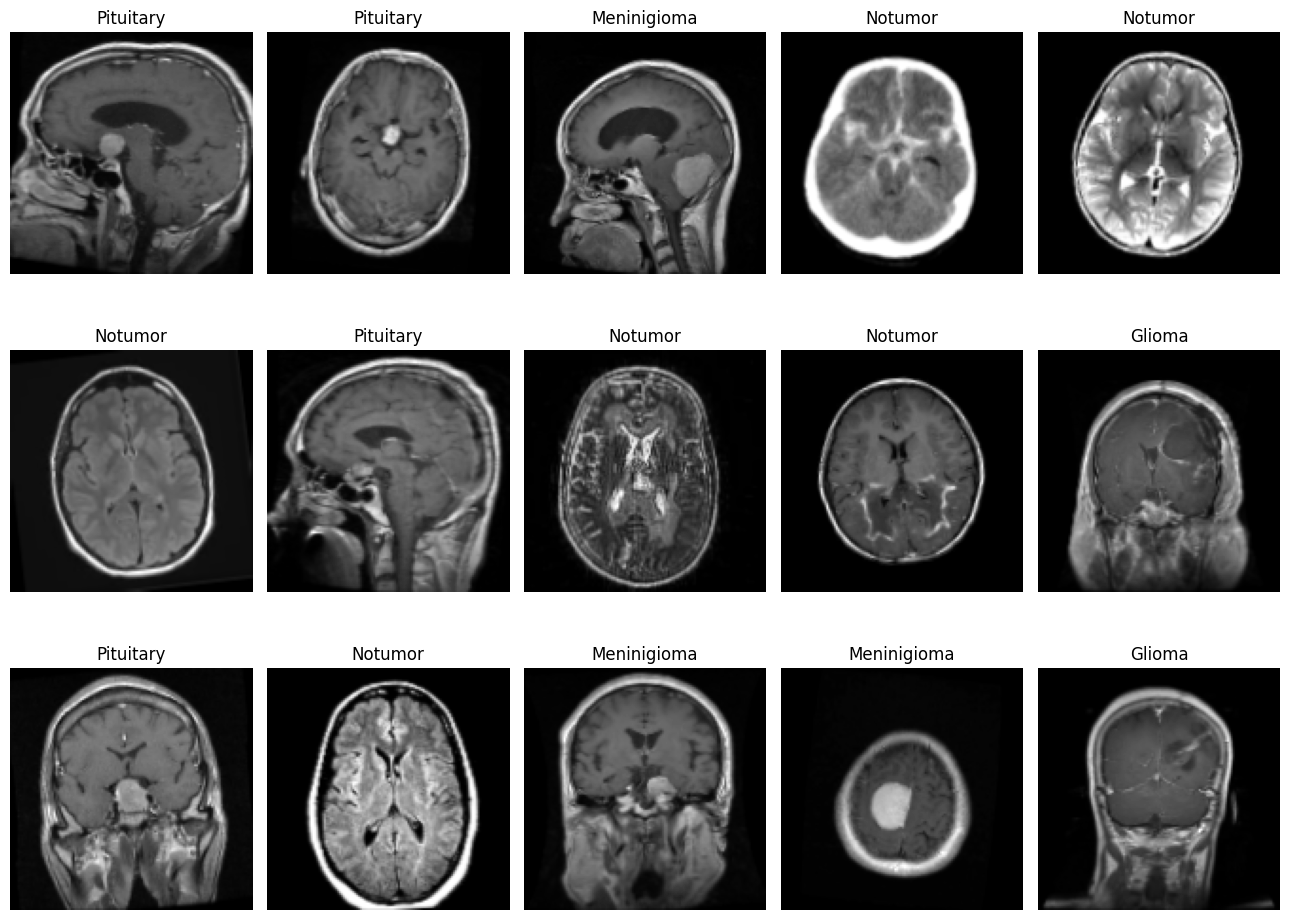

In [12]:
plot_augmented_images(train_ds_preprocessed, shape=(3, 5), class_mappings=class_mappings)

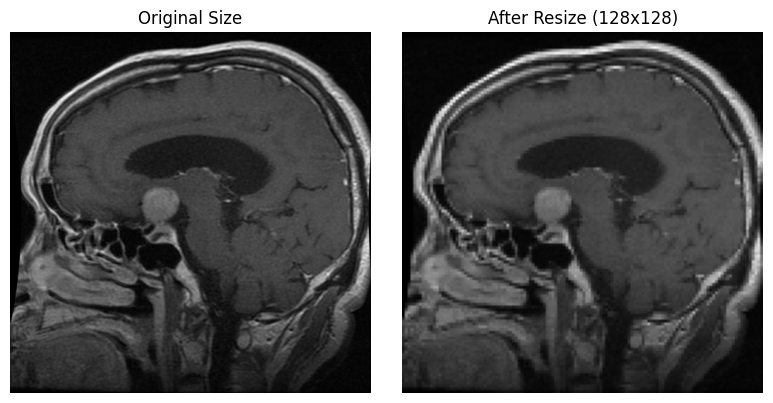

In [13]:
original_image_path = train_paths_sampled[0]
original_image = tf.io.read_file(original_image_path)
original_image = tf.image.decode_jpeg(original_image, channels=1)

resized_image = tf.image.resize(original_image, [128, 128])

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(tf.squeeze(original_image), cmap='gray')
plt.title('Original Size')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(tf.squeeze(resized_image), cmap='gray')
plt.title('After Resize (128x128)')
plt.axis('off')

plt.tight_layout()
plt.show()


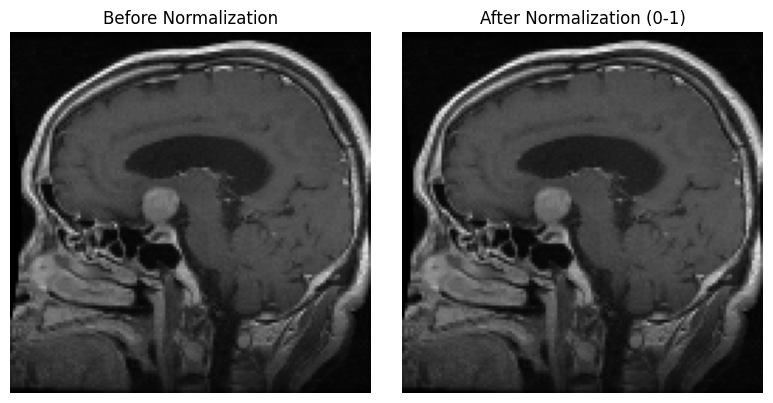

In [14]:
resized_image = tf.image.resize(original_image, [128, 128])

normalized_image = resized_image / 255.0

# Plot Before Normalization vs After Normalization

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(tf.squeeze(resized_image), cmap='gray')
plt.title('Before Normalization')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(tf.squeeze(normalized_image), cmap='gray')
plt.title('After Normalization (0-1)')
plt.axis('off')

plt.tight_layout()
plt.show()


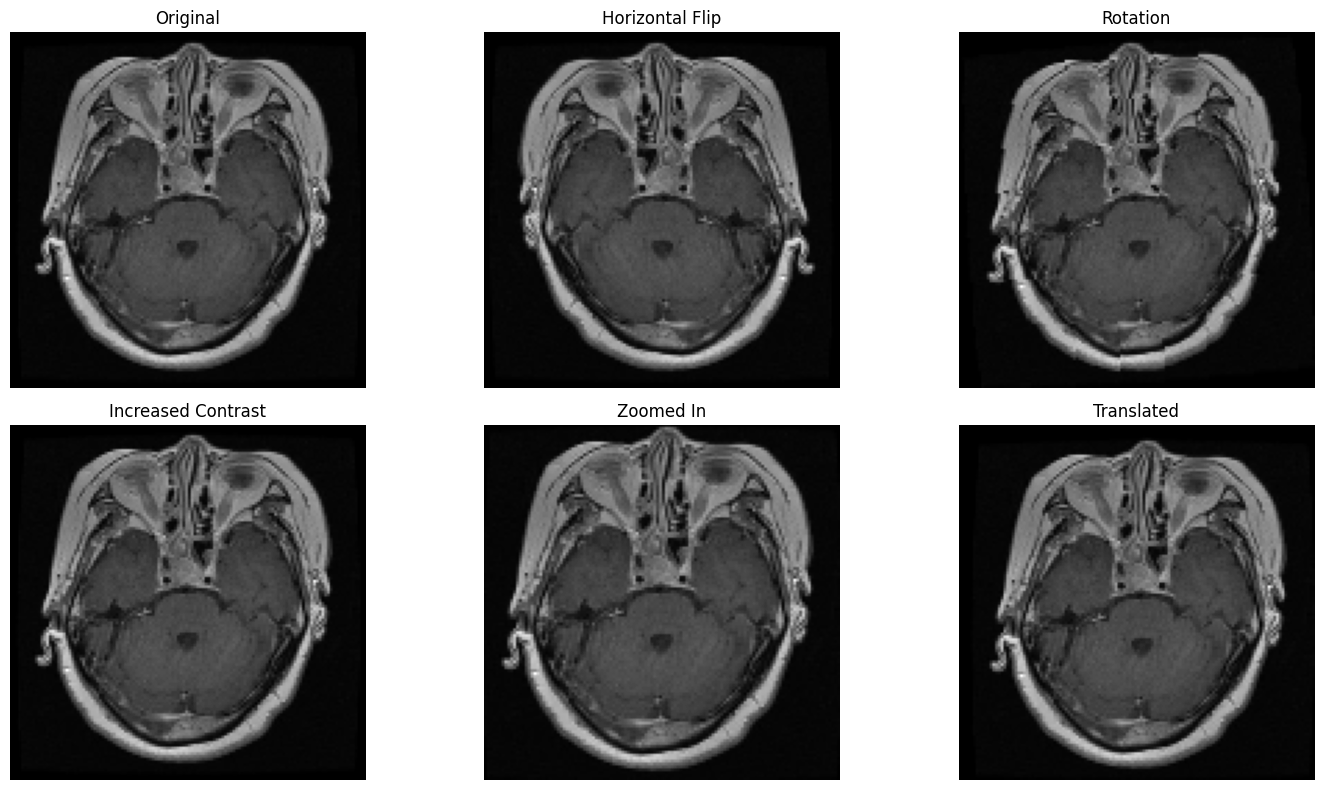

In [22]:
original_image_path = train_paths_sampled[15]
original_image = tf.io.read_file(original_image_path)
original_image = tf.image.decode_jpeg(original_image, channels=1)
original_image = tf.image.resize(original_image, [128, 128])

flipped_image = tf.image.flip_left_right(original_image)
rotated_image = tfa.image.rotate(original_image, 0.02 * 3.1416)  # 0.02 radians ≈ 1 degree
contrast_image = tf.image.adjust_contrast(original_image, 1.1)
zoomed_image = tf.image.central_crop(original_image, central_fraction=0.95)
translated_image = tfa.image.translate(original_image, [2, 2])

plt.figure(figsize=(15, 8))

# 1. Original
plt.subplot(2, 3, 1)
plt.imshow(tf.squeeze(original_image), cmap='gray')
plt.title('Original')
plt.axis('off')

# 2. Flipped
plt.subplot(2, 3, 2)
plt.imshow(tf.squeeze(flipped_image), cmap='gray')
plt.title('Horizontal Flip')
plt.axis('off')

# 3. Rotated
plt.subplot(2, 3, 3)
plt.imshow(tf.squeeze(rotated_image), cmap='gray')
plt.title('Rotation')
plt.axis('off')

# 4. Contrast Adjusted
plt.subplot(2, 3, 4)
plt.imshow(tf.squeeze(contrast_image), cmap='gray')
plt.title('Increased Contrast')
plt.axis('off')

# 5. Zoomed
plt.subplot(2, 3, 5)
plt.imshow(tf.squeeze(zoomed_image), cmap='gray')
plt.title('Zoomed In')
plt.axis('off')

# 6. Translated
plt.subplot(2, 3, 6)
plt.imshow(tf.squeeze(translated_image), cmap='gray')
plt.title('Translated')
plt.axis('off')

plt.tight_layout()
plt.show()


In [23]:
num_classes = len(class_mappings.keys())
image_shape = (image_dim[0], image_dim[1], 1)

epochs = 50
print(f'Number of Classes: {num_classes}')
print(f'Image shape: {image_shape}')
print(f'Epochs: {epochs}')
print(f'Batch size: {batch_size}')

# One-Hot coding for labels to use Categorical Cross entropy loss metric

def encode_labels(image, label):
    return image, tf.one_hot(label, depth=num_classes)

train_ds_preprocessed = train_ds_preprocessed.map(encode_labels, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_preprocessed = test_ds_preprocessed.map(encode_labels, num_parallel_calls=tf.data.AUTOTUNE)

Number of Classes: 4
Image shape: (128, 128, 1)
Epochs: 50
Batch size: 32


In [24]:
print("Normal labels (before one-hot encoding):")
print(train_index_sampled[:10])  

Normal labels (before one-hot encoding):
[3, 3, 1, 2, 2, 2, 3, 2, 2, 0]


In [25]:
for images, labels in train_ds_preprocessed.take(1):
    print("One-hot encoded labels:")
    print(labels.numpy()[:10])  

One-hot encoded labels:
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]]


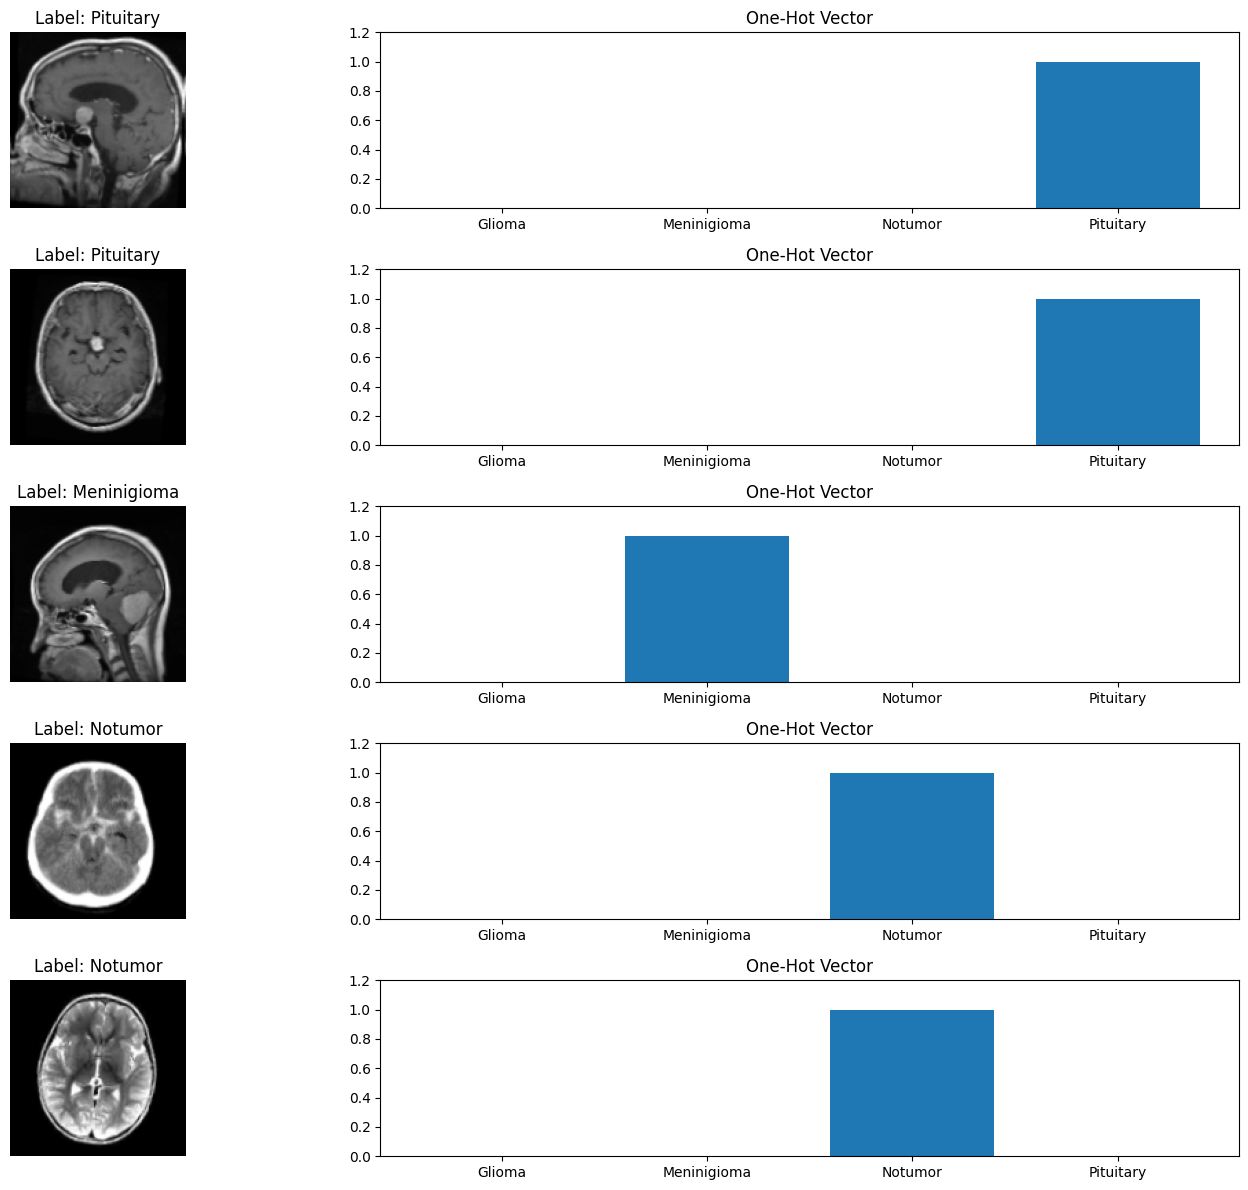

In [26]:
for images, labels in train_ds_preprocessed.take(1):
    one_hot_labels = labels.numpy()

normal_labels = np.argmax(one_hot_labels, axis=1)

fig, axs = plt.subplots(5, 2, figsize=(16, 12))

for i in range(5):
    axs[i, 0].imshow(tf.squeeze(images[i]), cmap='gray')
    axs[i, 0].axis('off')
    label_name = class_names[normal_labels[i]]  
    axs[i, 0].set_title(f"Label: {label_name}")

    axs[i, 1].bar(range(num_classes), one_hot_labels[i])
    axs[i, 1].set_xticks(range(num_classes))
    axs[i, 1].set_xticklabels(class_names)
    axs[i, 1].set_ylim(0, 1.2)
    axs[i, 1].set_title("One-Hot Vector")

plt.tight_layout()
plt.show()

In [27]:
# Custom callback for reducing learning rate at accuracy values

class ReduceLROnMultipleAccuracies(tf.keras.callbacks.Callback):
    def __init__(self, thresholds, factor, monitor='val_accuracy', verbose=1):
        super(ReduceLROnMultipleAccuracies, self).__init__()
        self.thresholds = thresholds  
        self.factor = factor  
        self.monitor = monitor
        self.verbose = verbose
        self.thresholds_reached = [False] * len(thresholds) 

    def on_epoch_end(self, epoch, logs=None):
        current_accuracy = logs.get(self.monitor)
        for i, threshold in enumerate(self.thresholds):
            if current_accuracy >= threshold and not self.thresholds_reached[i]:
                optimizer = self.model.optimizer
                old_lr = optimizer.learning_rate.numpy()
                new_lr = old_lr * self.factor
                optimizer.learning_rate.assign(new_lr)
                self.thresholds_reached[i] = True  
                if self.verbose > 0:
                    print(f"\nEpoch {epoch+1}: {self.monitor} reached {threshold}. Reducing learning rate from {old_lr} to {new_lr}.")

thresholds = [0.91, 0.94, 0.97]
lr_callback = ReduceLROnMultipleAccuracies(thresholds=thresholds, factor=0.65, monitor='val_accuracy', verbose=False) 

In [28]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor ='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

In [ ]:
# CNN Model creation

image_height = 128
image_width = 128
channels = 1
num_classes = 4  

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(image_height, image_width, channels)),
    # First Convolutional Layer
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third Convolutional Layer
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax')  
])

In [17]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 126, 126, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 61, 61, 64)       256       
 hNormalization)                                                 
                                                      

In [18]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
history = model.fit(
    train_ds_preprocessed,
    validation_data=test_ds_preprocessed,
    epochs=50,
    callbacks=[lr_callback,reduce_lr],   
    verbose=True
)

Epoch 1/50
125/125 [==============================] - 110s 803ms/step - loss: 1.0692 - accuracy: 0.7115 - val_loss: 22.1654 - val_accuracy: 0.2288 - lr: 5.0000e-04
Epoch 2/50
125/125 [==============================] - 94s 726ms/step - loss: 0.5477 - accuracy: 0.7952 - val_loss: 13.1745 - val_accuracy: 0.2311 - lr: 5.0000e-04
Epoch 3/50
125/125 [==============================] - 95s 733ms/step - loss: 0.4302 - accuracy: 0.8365 - val_loss: 1.0228 - val_accuracy: 0.6690 - lr: 5.0000e-04
Epoch 4/50
125/125 [==============================] - 94s 725ms/step - loss: 0.3696 - accuracy: 0.8645 - val_loss: 0.5930 - val_accuracy: 0.7681 - lr: 5.0000e-04
Epoch 5/50
125/125 [==============================] - 94s 719ms/step - loss: 0.3107 - accuracy: 0.8805 - val_loss: 0.3956 - val_accuracy: 0.8429 - lr: 5.0000e-04
Epoch 6/50
125/125 [==============================] - 92s 703ms/step - loss: 0.2820 - accuracy: 0.8870 - val_loss: 0.3603 - val_accuracy: 0.8680 - lr: 5.0000e-04
Epoch 7/50
125/125 [=====

In [21]:
test_loss, test_acc = model.evaluate(test_ds_preprocessed)
print(f"Test accuracy: {test_acc*100:0.4f}%")
print(f"Test loss: {test_loss*100:0.4f}%")

41/41 [==============================] - 7s 165ms/step - loss: 0.3132 - accuracy: 0.9375
Test accuracy: 93.7452%
Test loss: 31.3245%


In [ ]:
K.clear_session()

In [ ]:
# LSTM Model creation

lstm_model = Sequential([
    tf.keras.layers.Input(shape=(128, 128, 1)),  

    tf.keras.layers.Reshape((128, 128)),

    # First LSTM layer
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Dropout(0.3),

    # Second LSTM layer
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

In [26]:
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(0.0005),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

history_lstm = lstm_model.fit(
    train_ds_preprocessed, 
    validation_data=test_ds_preprocessed,
    epochs=50,
    callbacks=[lr_callback, reduce_lr],
    verbose=True
)

Epoch 1/50
125/125 [==============================] - 85s 526ms/step - loss: 1.1872 - accuracy: 0.4845 - val_loss: 1.0363 - val_accuracy: 0.5622 - lr: 5.0000e-04
Epoch 2/50
125/125 [==============================] - 48s 372ms/step - loss: 0.9685 - accuracy: 0.6085 - val_loss: 0.9096 - val_accuracy: 0.6285 - lr: 5.0000e-04
Epoch 3/50
125/125 [==============================] - 46s 356ms/step - loss: 0.9024 - accuracy: 0.6482 - val_loss: 0.8839 - val_accuracy: 0.6430 - lr: 5.0000e-04
Epoch 4/50
125/125 [==============================] - 45s 348ms/step - loss: 0.8010 - accuracy: 0.6923 - val_loss: 0.7944 - val_accuracy: 0.6934 - lr: 5.0000e-04
Epoch 5/50
125/125 [==============================] - 44s 341ms/step - loss: 0.7913 - accuracy: 0.7057 - val_loss: 0.8852 - val_accuracy: 0.6461 - lr: 5.0000e-04
Epoch 6/50
125/125 [==============================] - 52s 404ms/step - loss: 0.7514 - accuracy: 0.7165 - val_loss: 0.8076 - val_accuracy: 0.6781 - lr: 5.0000e-04
Epoch 7/50
125/125 [========

In [27]:
test_loss_lstm, test_acc_lstm = lstm_model.evaluate(test_ds_preprocessed)
print(f"Test accuracy: {test_acc_lstm*100:0.4f}%")
print(f"Test loss: {test_loss_lstm*100:0.4f}%")

41/41 [==============================] - 12s 268ms/step - loss: 0.4720 - accuracy: 0.8307
Test accuracy: 83.0664%
Test loss: 47.2004%


In [ ]:
# CNN + LSTM Hybrid model creation

image_height = 128
image_width = 128
channels = 1
num_classes = 4

CNN_LSTM_model = models.Sequential([
    # First Convolutional layer
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(image_height, image_width, channels)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional layer
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional layer
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Reshape((16 * 16, 128)),

    # LSTM Layer
    layers.LSTM(64),

    # Final Dense Layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])


In [ ]:
CNN_LSTM_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

CNN_LSTM_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 64)       256       
 hNormalization)                                                 
                                                      

In [ ]:
K.clear_session()

In [35]:
CNN_LSTM_history = CNN_LSTM_model.fit(
    train_ds_preprocessed,
    validation_data=test_ds_preprocessed,
    epochs=50,
    callbacks=[lr_callback, reduce_lr],
    verbose=True
)

Epoch 1/50
125/125 [==============================] - 128s 979ms/step - loss: 0.9375 - accuracy: 0.6012 - val_loss: 1.6469 - val_accuracy: 0.2288 - lr: 5.0000e-04
Epoch 2/50
125/125 [==============================] - 107s 831ms/step - loss: 0.7861 - accuracy: 0.6743 - val_loss: 1.9229 - val_accuracy: 0.2304 - lr: 5.0000e-04
Epoch 3/50
125/125 [==============================] - 107s 827ms/step - loss: 0.7227 - accuracy: 0.7185 - val_loss: 1.8486 - val_accuracy: 0.2799 - lr: 5.0000e-04
Epoch 4/50
125/125 [==============================] - 108s 838ms/step - loss: 0.6505 - accuracy: 0.7458 - val_loss: 1.4415 - val_accuracy: 0.4477 - lr: 5.0000e-04
Epoch 5/50
125/125 [==============================] - 108s 842ms/step - loss: 0.5975 - accuracy: 0.7782 - val_loss: 1.2806 - val_accuracy: 0.5118 - lr: 5.0000e-04
Epoch 6/50
125/125 [==============================] - 107s 828ms/step - loss: 0.5760 - accuracy: 0.7795 - val_loss: 1.3257 - val_accuracy: 0.4966 - lr: 5.0000e-04
Epoch 7/50
125/125 [==

In [36]:
test_loss_cnn_lstm, test_acc_cnn_lstm = CNN_LSTM_model.evaluate(test_ds_preprocessed)
print(f"Test accuracy: {test_acc_cnn_lstm*100:0.4f}%")
print(f"Test loss: {test_loss_cnn_lstm*100:0.4f}%")

41/41 [==============================] - 24s 578ms/step - loss: 0.4972 - accuracy: 0.8497
Test accuracy: 84.9733%
Test loss: 49.7179%


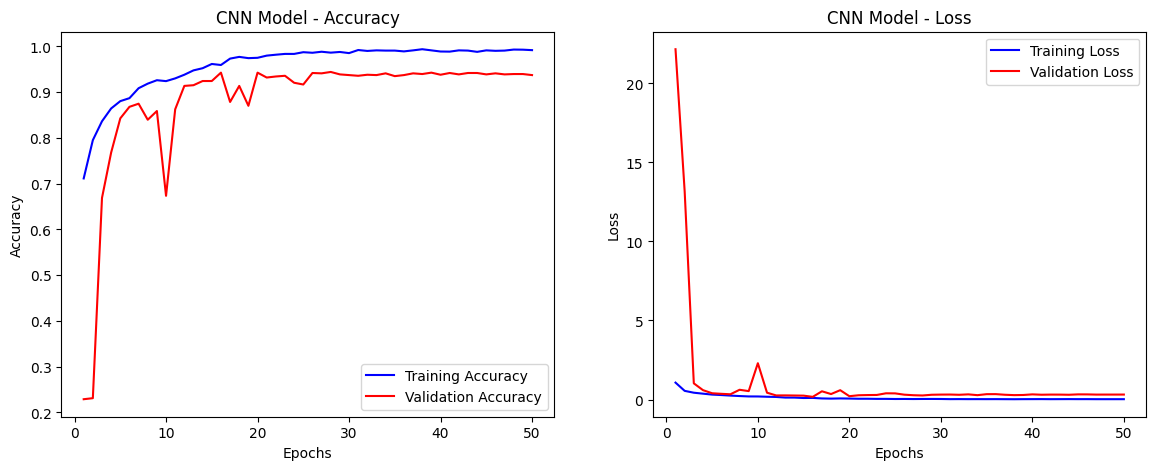

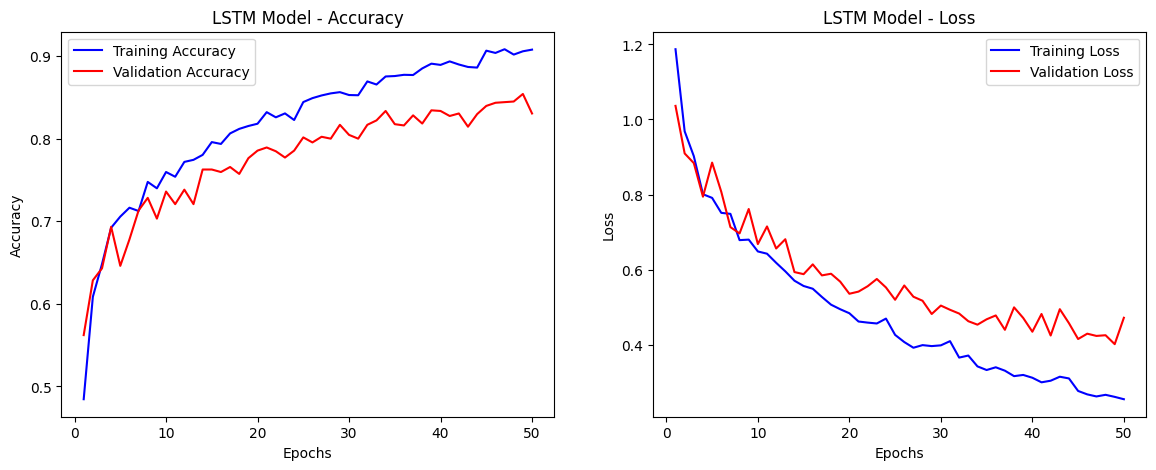

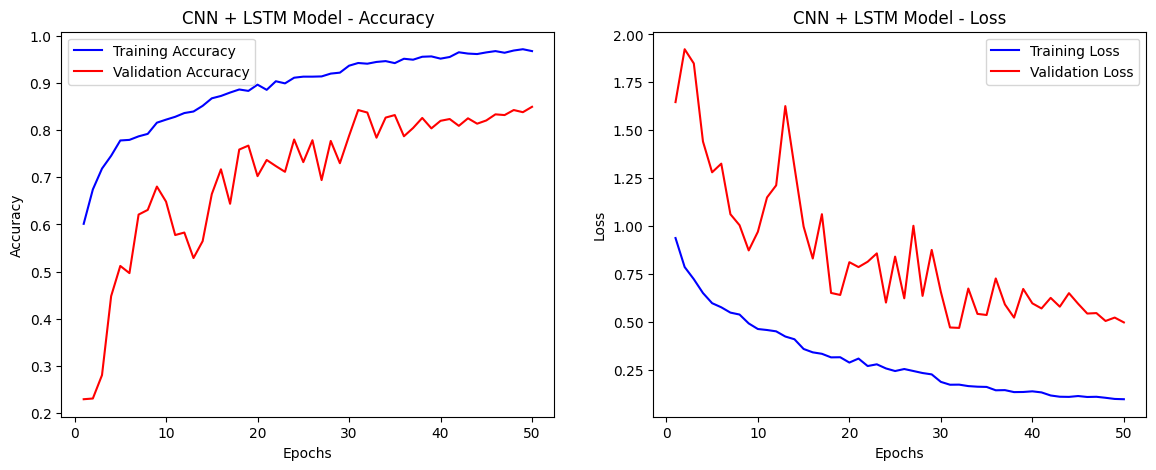

In [ ]:
def plot_training_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_history(history, "CNN Model")
plot_training_history(history_lstm, "LSTM Model")
plot_training_history(CNN_LSTM_history, "CNN + LSTM Model")

Grad-CAM for CNN model:


C:\Users\nanda\AppData\Local\Temp\ipykernel_6068\34852815.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


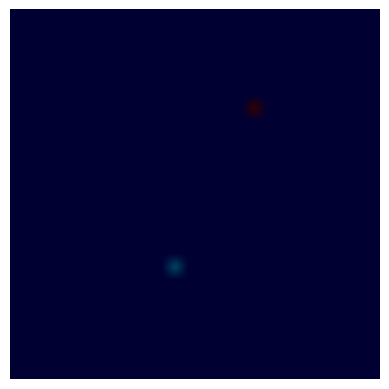

Grad-CAM for CNN+LSTM model:


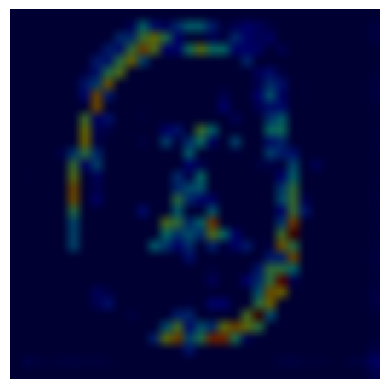


Grad-CAM cannot be generated for pure LSTM models (no Conv layers) ❌.


In [ ]:
# Grad-CAM 

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last conv layer + output
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradient of the top predicted class for the input image
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(image, heatmap, alpha=0.4):
    if not isinstance(image, np.ndarray):
        image = np.array(image)

    if len(image.shape) == 2:   
        image = np.stack([image, image, image], axis=-1)

    heatmap = np.uint8(255 * heatmap)

    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = np.uint8(jet_heatmap * 255)

    jet_heatmap = tf.image.resize(jet_heatmap, (image.shape[0], image.shape[1])).numpy()

    superimposed_img = jet_heatmap * alpha + image
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()


sample_image, sample_label = next(iter(test_ds_preprocessed))
sample_image = sample_image[0]  
sample_label = sample_label[0]

sample_image_expanded = np.expand_dims(sample_image, axis=0)

# 1. For CNN model
last_conv_layer_name_cnn = "conv2d_2"  # You can check model.summary() to confirm last conv layer name
heatmap_cnn = make_gradcam_heatmap(sample_image_expanded, model, last_conv_layer_name_cnn)

print("Grad-CAM for CNN model:")
display_gradcam(np.squeeze(sample_image.numpy()), heatmap_cnn)

# 2. For CNN+LSTM model
last_conv_layer_name_cnnlstm = "conv2d_2"  # Check CNN_LSTM_model.summary() for correct layer name
heatmap_cnnlstm = make_gradcam_heatmap(sample_image_expanded, CNN_LSTM_model, last_conv_layer_name_cnnlstm)

print("Grad-CAM for CNN+LSTM model:")
display_gradcam(np.squeeze(sample_image.numpy()), heatmap_cnnlstm)

# 3. For LSTM model
print("\nGrad-CAM cannot be generated for pure LSTM models (no Conv layers) ❌.")


41/41 [==============================] - 11s 233ms/step


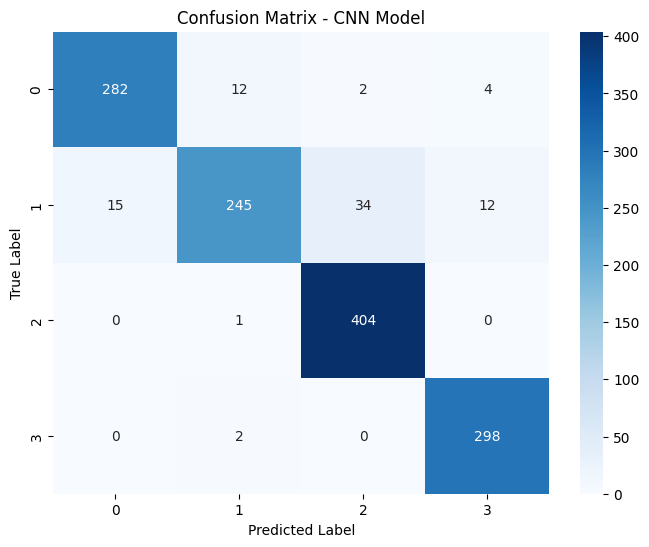

Classification Report for CNN Model:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       300
           1       0.94      0.80      0.87       306
           2       0.92      1.00      0.96       405
           3       0.95      0.99      0.97       300

    accuracy                           0.94      1311
   macro avg       0.94      0.93      0.93      1311
weighted avg       0.94      0.94      0.94      1311



41/41 [==============================] - 15s 236ms/step


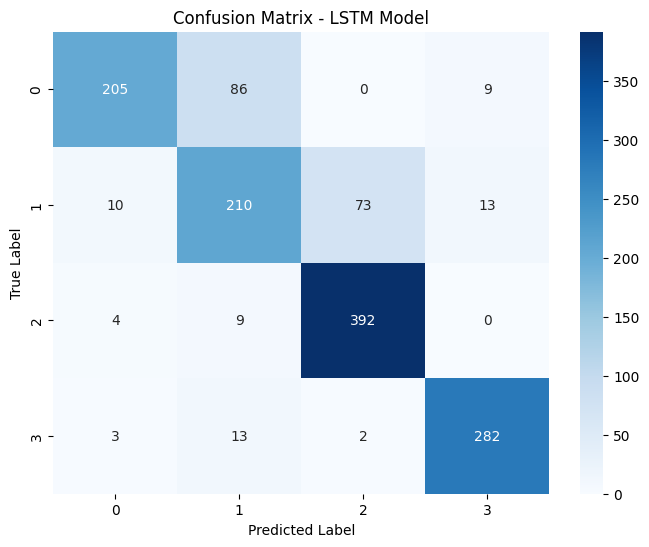

Classification Report for LSTM Model:

              precision    recall  f1-score   support

           0       0.92      0.68      0.79       300
           1       0.66      0.69      0.67       306
           2       0.84      0.97      0.90       405
           3       0.93      0.94      0.93       300

    accuracy                           0.83      1311
   macro avg       0.84      0.82      0.82      1311
weighted avg       0.84      0.83      0.83      1311



41/41 [==============================] - 14s 265ms/step


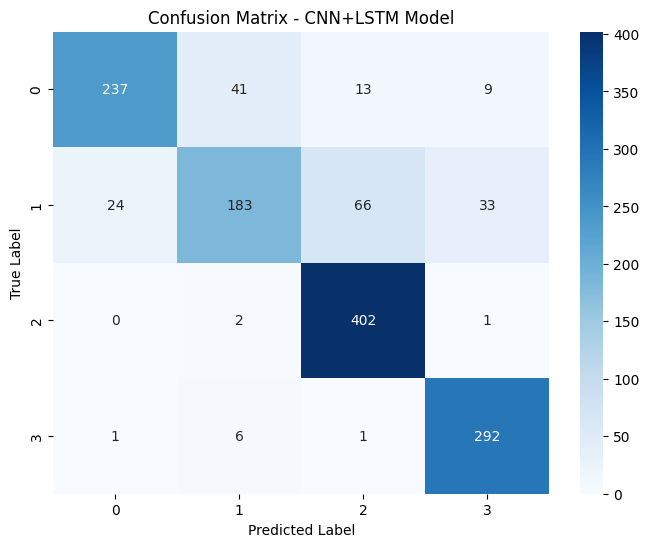

Classification Report for CNN+LSTM Model:

              precision    recall  f1-score   support

           0       0.90      0.79      0.84       300
           1       0.79      0.60      0.68       306
           2       0.83      0.99      0.91       405
           3       0.87      0.97      0.92       300

    accuracy                           0.85      1311
   macro avg       0.85      0.84      0.84      1311
weighted avg       0.85      0.85      0.84      1311





In [ ]:
def plot_confusion_matrix(model, test_ds, model_name="Model"):
    y_true = np.concatenate([y for x, y in test_ds], axis=0)

    y_pred = model.predict(test_ds)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_true, axis=1)

    cm = confusion_matrix(y_true_classes, y_pred_classes)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_true_classes, y_pred_classes))
    print("\n" + "="*60 + "\n")

# For CNN model
plot_confusion_matrix(model, test_ds_preprocessed, "CNN Model")

# For LSTM model
plot_confusion_matrix(lstm_model, test_ds_preprocessed, "LSTM Model")

# For CNN+LSTM model
plot_confusion_matrix(CNN_LSTM_model, test_ds_preprocessed, "CNN+LSTM Model")


In [67]:
# Example for CNN model
y_pred_probs_cnn = model.predict(test_ds_preprocessed)

# Example for CNN+LSTM model
y_pred_probs_cnnlstm = CNN_LSTM_model.predict(test_ds_preprocessed)

# Example for LSTM model
y_pred_probs_lstm = lstm_model.predict(test_ds_preprocessed)


41/41 [==============================] - 3s 63ms/step


In [ ]:
# Binarize the true labels
y_true_binarized = label_binarize(test_index, classes=[0, 1, 2, 3])

In [ ]:
# ROC Curve Plotting

def plot_roc_curves(y_true_binarized, y_pred_probs, model_name, class_names):
    plt.figure(figsize=(10, 8))

    colors = ['blue', 'red', 'green', 'purple']  

    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='black', linestyle='--')  
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()


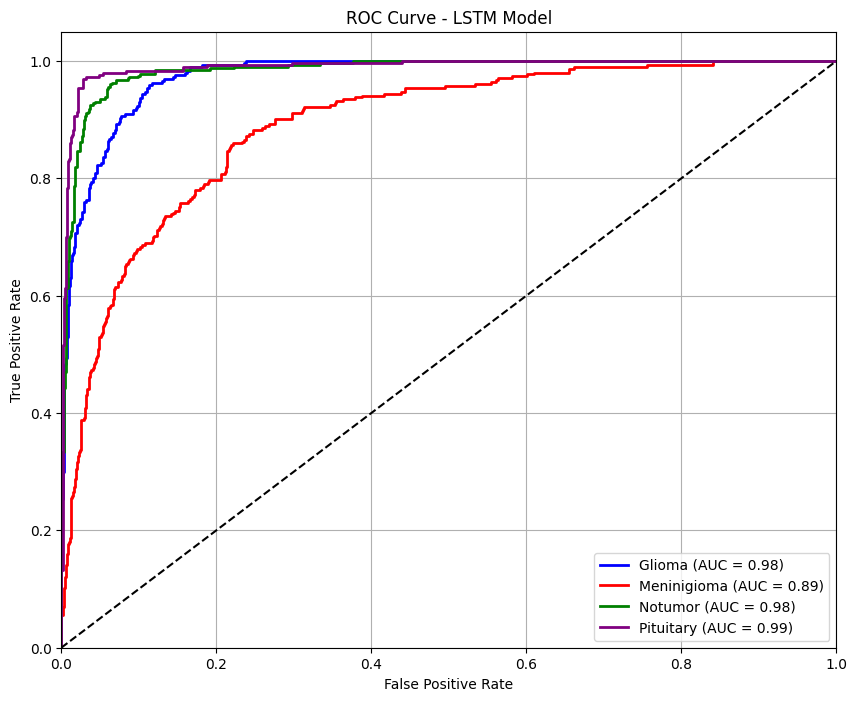

In [ ]:
plot_roc_curves(y_true_binarized, y_pred_probs_lstm, "LSTM Model", class_names)

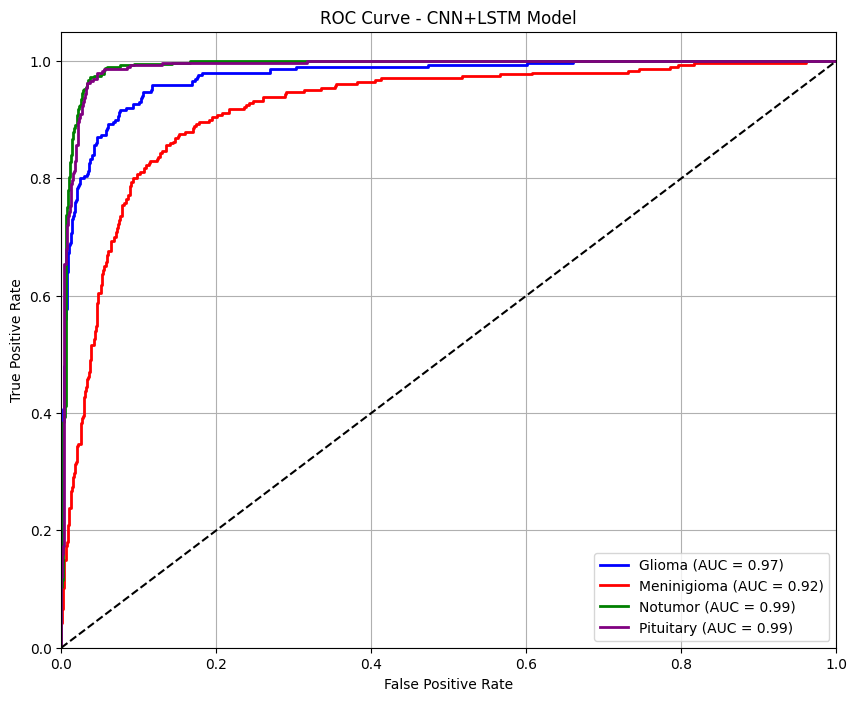

In [ ]:
plot_roc_curves(y_true_binarized, y_pred_probs_cnnlstm, "CNN+LSTM Model", class_names)

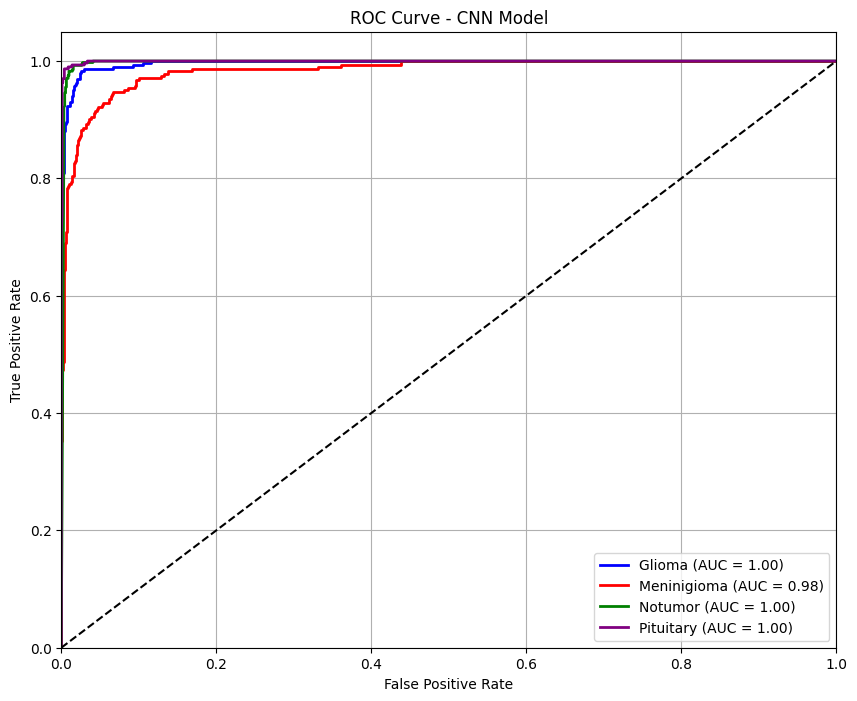

In [ ]:
plot_roc_curves(y_true_binarized, y_pred_probs_cnn, "CNN Model", class_names)

In [ ]:
def get_correct_wrong_preds(y_pred_probs, y_true):
    correct_preds = []
    wrong_preds = []

    for idx in range(len(y_true)):
        true_label = y_true[idx]
        pred_label = np.argmax(y_pred_probs[idx])  

        if pred_label == true_label:
            correct_preds.append((test_paths[idx], true_label, pred_label))
        else:
            wrong_preds.append((test_paths[idx], true_label, pred_label))

    print(f"✅ Correct: {len(correct_preds)} | ❌ Wrong: {len(wrong_preds)}")
    return correct_preds, wrong_preds

# Get correct & wrong predictions for each model

correct_cnn, wrong_cnn = get_correct_wrong_preds(y_pred_probs_cnn, test_index)
correct_cnnlstm, wrong_cnnlstm = get_correct_wrong_preds(y_pred_probs_cnnlstm, test_index)
correct_lstm, wrong_lstm = get_correct_wrong_preds(y_pred_probs_lstm, test_index)


✅ Correct: 1229 | ❌ Wrong: 82
✅ Correct: 1114 | ❌ Wrong: 197
✅ Correct: 1089 | ❌ Wrong: 222


In [ ]:
def visualize_predictions(pred_list, title, num_samples=8):
    plt.figure(figsize=(16, 10))
    sample_preds = pred_list[:num_samples]  

    for i, (image_path, true_label, pred_label) in enumerate(sample_preds):
        image_string = tf.io.read_file(image_path)
        image = tf.image.decode_jpeg(image_string, channels=1)
        image = tf.image.resize(image, (128, 128))
        image = tf.squeeze(image) 

        color = "green" if true_label == pred_label else "red"
        plt.subplot(2, 4, i + 1)
        plt.imshow(image, cmap='gray')
        plt.axis('off')
        plt.title(f"True: {index_to_class[true_label]}\nPred: {index_to_class[pred_label]}", 
                  fontsize=10, color=color)

    plt.suptitle(title, fontsize=16, color=color)
    plt.tight_layout()
    plt.show()

C:\Users\nanda\AppData\Local\Temp\ipykernel_6068\3626702476.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nanda\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


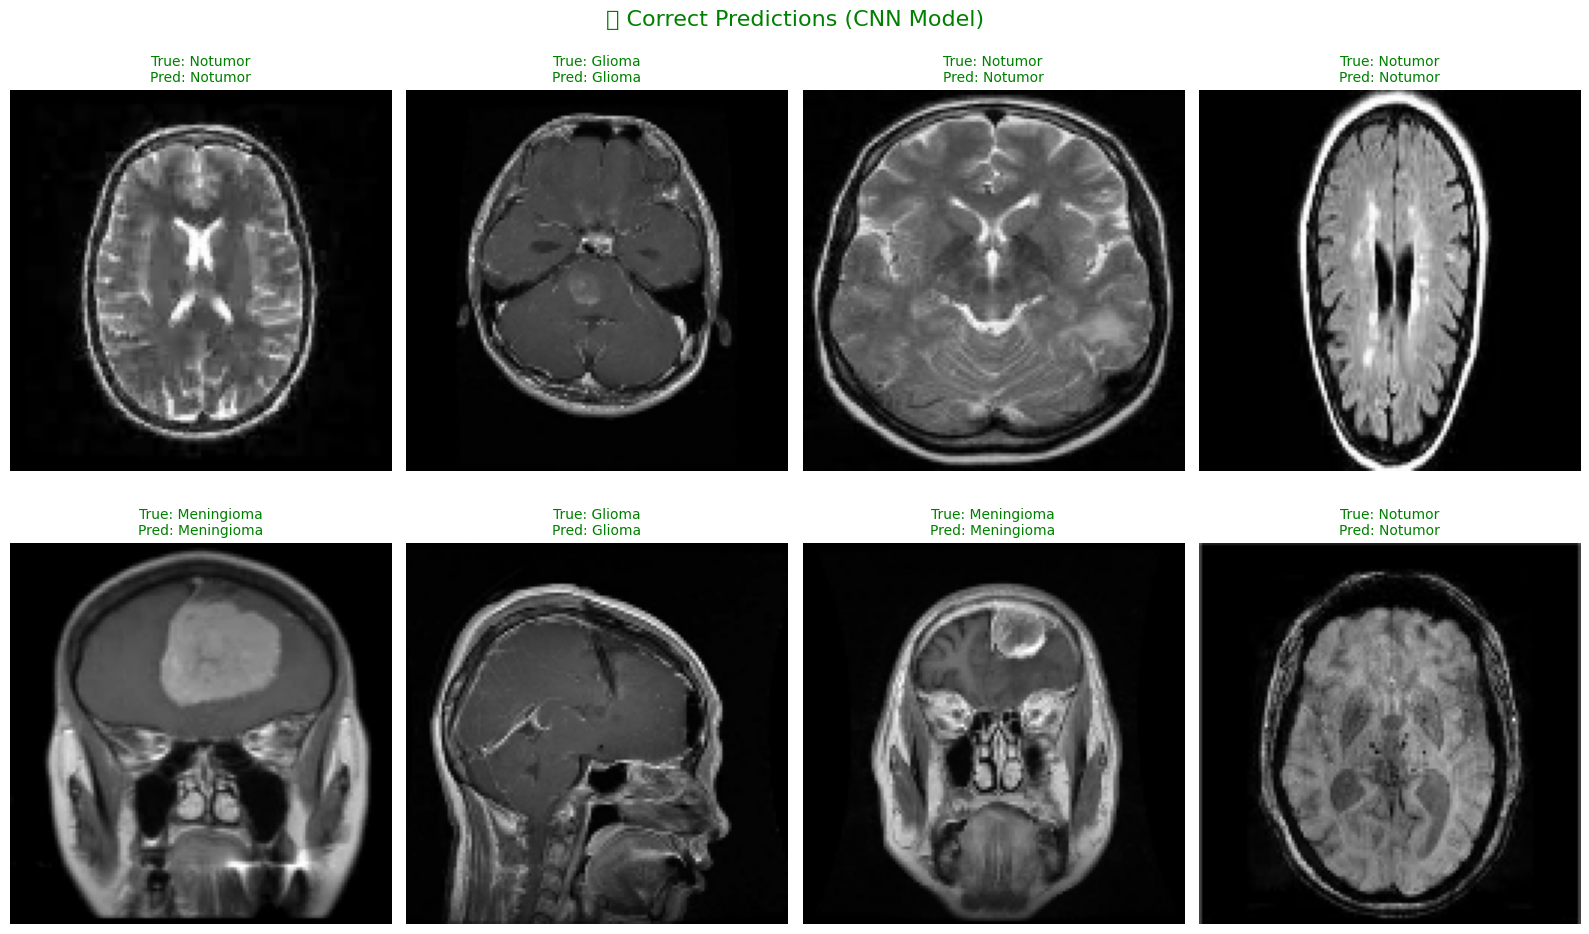

C:\Users\nanda\AppData\Local\Temp\ipykernel_6068\3626702476.py:23: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nanda\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


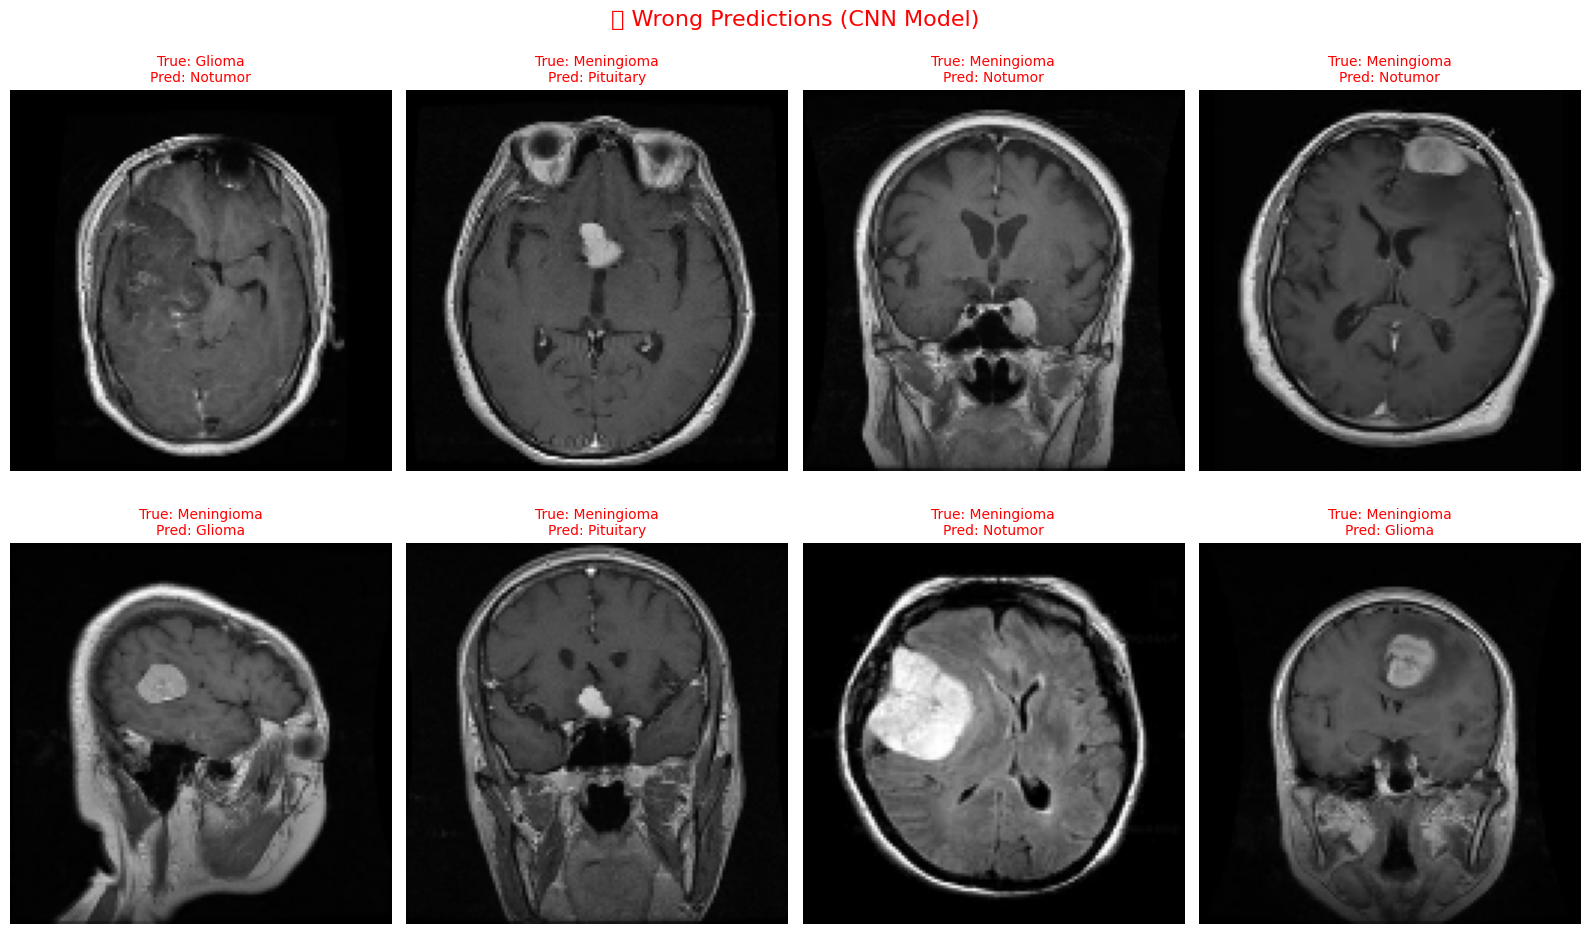

In [ ]:
visualize_predictions(correct_cnn, "Correct Predictions (CNN Model)")
visualize_predictions(wrong_cnn, "Wrong Predictions (CNN Model)")


C:\Users\nanda\AppData\Local\Temp\ipykernel_6068\3626702476.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


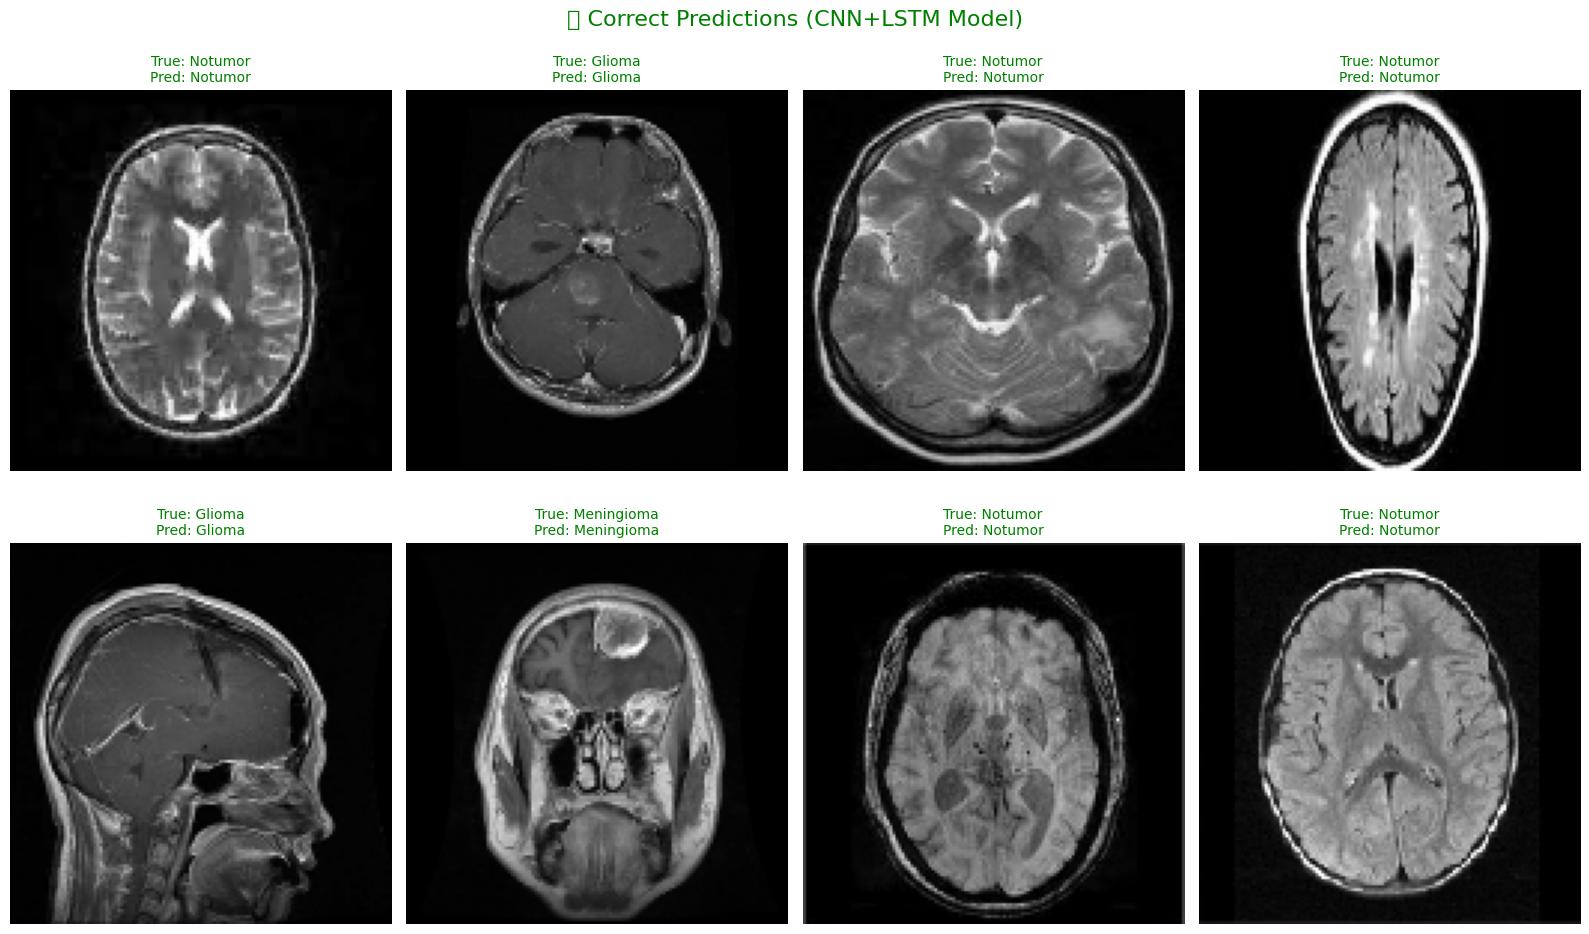

C:\Users\nanda\AppData\Local\Temp\ipykernel_6068\3626702476.py:23: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


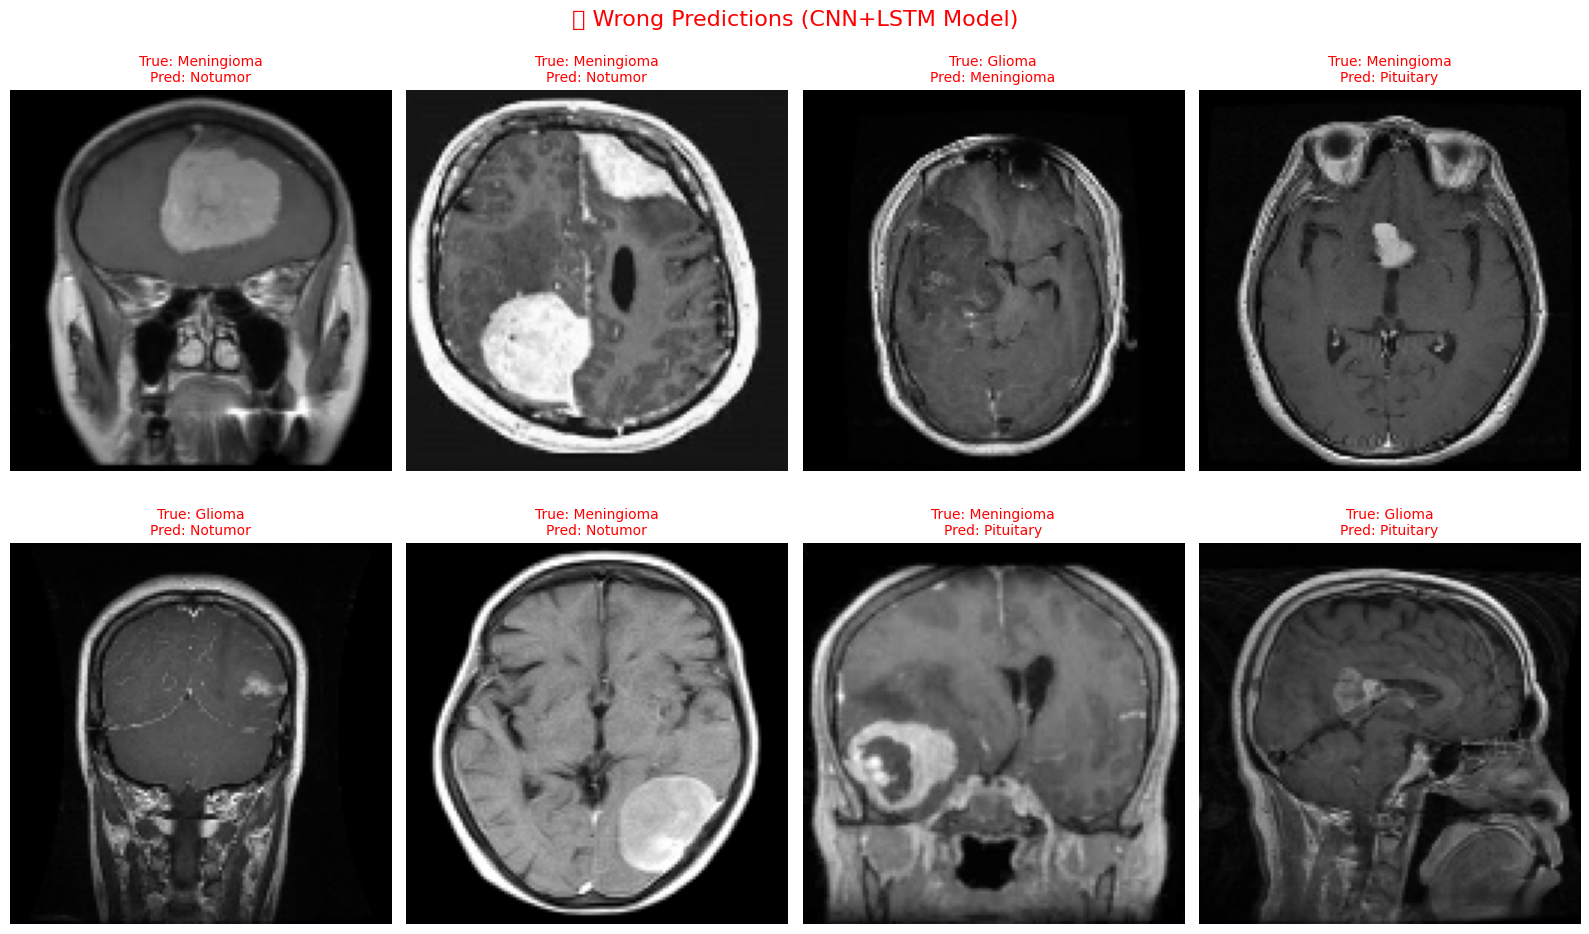

In [ ]:
visualize_predictions(correct_cnnlstm, "Correct Predictions (CNN+LSTM Model)")
visualize_predictions(wrong_cnnlstm, "Wrong Predictions (CNN+LSTM Model)")

C:\Users\nanda\AppData\Local\Temp\ipykernel_6068\3626702476.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


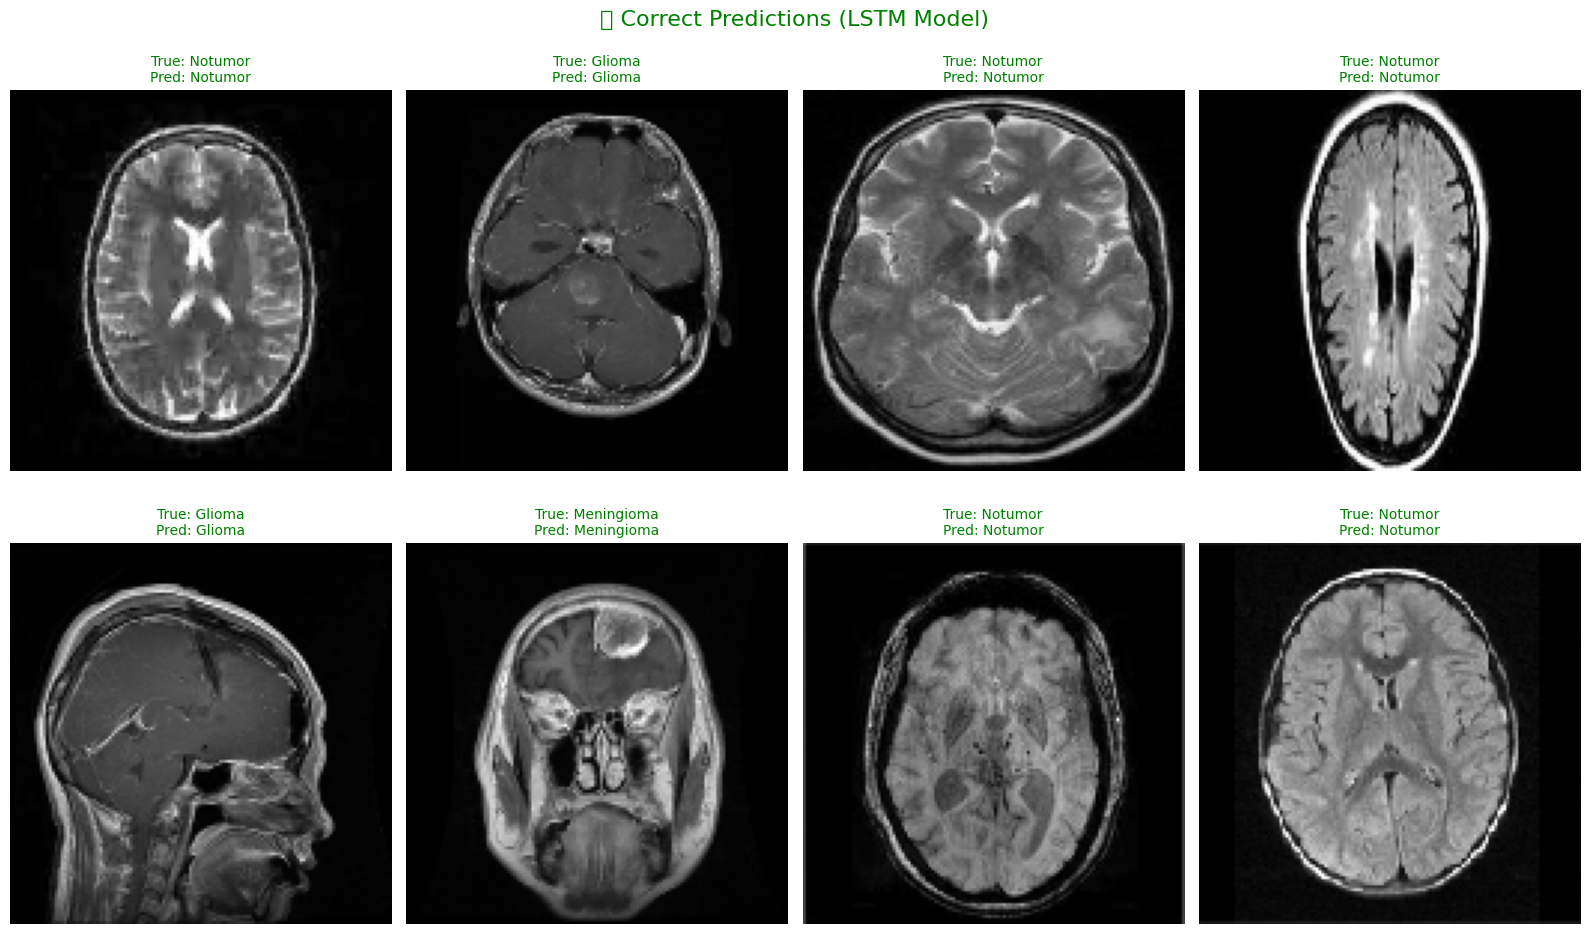

C:\Users\nanda\AppData\Local\Temp\ipykernel_6068\3626702476.py:23: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


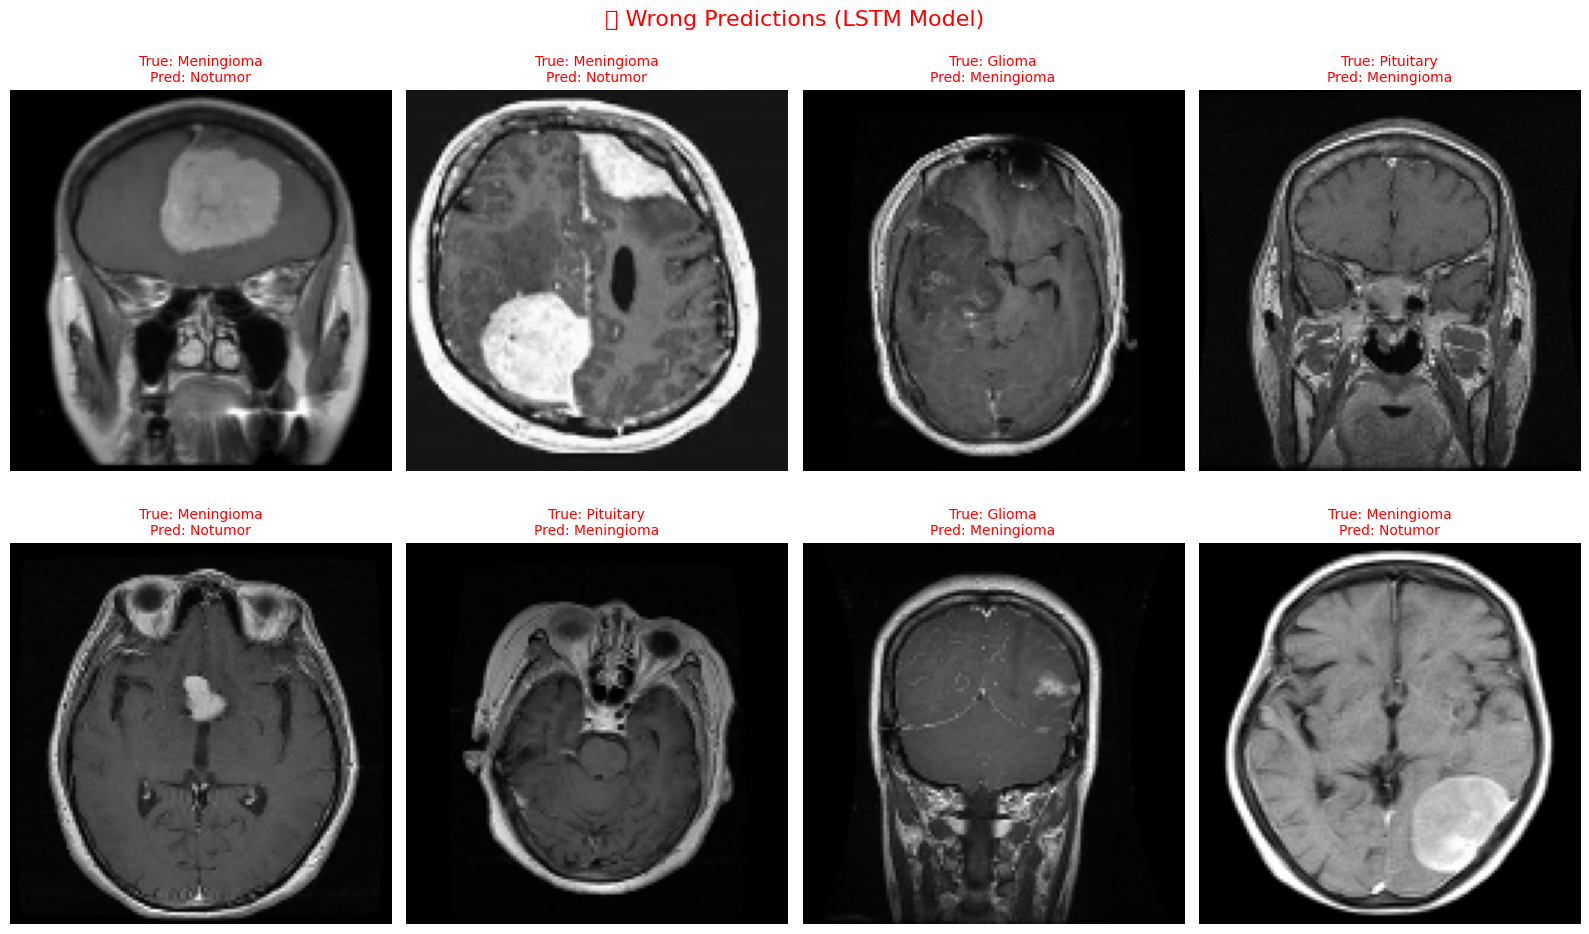

In [ ]:
visualize_predictions(correct_lstm, "Correct Predictions (LSTM Model)")
visualize_predictions(wrong_lstm, "Wrong Predictions (LSTM Model)")